# 📊 CEO Dashboard – Superstore KPI Overview
> **Mục tiêu:** Tổng quan hiệu suất kinh doanh cho Ban lãnh đạo – 4 KPI chính, biến động so với tháng/quý trước, và xu hướng Doanh số & Lợi nhuận theo Quý.

In [1]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('../data/Superstore.csv', encoding='latin1')
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True, errors='coerce')
df['Ship Date']  = pd.to_datetime(df['Ship Date'],  dayfirst=True, errors='coerce')
df['Year']    = df['Order Date'].dt.year
df['Month']   = df['Order Date'].dt.to_period('M')
df['Quarter'] = df['Order Date'].dt.to_period('Q')

print(f'Loaded {len(df):,} rows | {df["Order Date"].min().date()} to {df["Order Date"].max().date()}')
df[['Order Date','Sales','Profit','Quantity']].head(3)


Loaded 9,994 rows | 2011-01-04 to 2014-12-31


,Order Date,Sales,Profit,Quantity
0,2013-11-09,261.96,41.9136,2
1,2013-11-09,731.94,219.5820,3
2,2013-06-13,14.62,6.8714,2


In [2]:
def kpi_period(period_col, target):
    sub = df[period_col == target]
    s = sub['Sales'].sum()
    p = sub['Profit'].sum()
    o = sub['Order ID'].nunique()
    m = (p / s * 100) if s > 0 else 0
    return {'sales': s, 'profit': p, 'orders': o, 'margin': m}

def pct_change(curr, prev):
    if prev == 0: return 0.0
    return (curr - prev) / abs(prev) * 100

latest_month   = df['Month'].max()
prev_month     = latest_month - 1
cur_m   = kpi_period(df['Month'], latest_month)
prev_m  = kpi_period(df['Month'], prev_month)

latest_quarter = df['Quarter'].max()
prev_quarter   = latest_quarter - 1
cur_q   = kpi_period(df['Quarter'], latest_quarter)
prev_q  = kpi_period(df['Quarter'], prev_quarter)

total_sales  = df['Sales'].sum()
total_profit = df['Profit'].sum()
total_orders = df['Order ID'].nunique()
total_margin = total_profit / total_sales * 100

print(f'Period: {latest_month} vs {prev_month} | {latest_quarter} vs {prev_quarter}')
print(f'Sales: ${total_sales:,.0f} | Profit: ${total_profit:,.0f} | Orders: {total_orders} | Margin: {total_margin:.1f}%')


Period: 2014-12 vs 2014-11 | 2014Q4 vs 2014Q3
Sales: $2,297,201 | Profit: $286,397 | Orders: 5009 | Margin: 12.5%


In [3]:
quarterly = (
    df.groupby('Quarter')
      .agg(Sales=('Sales','sum'), Profit=('Profit','sum'))
      .reset_index().sort_values('Quarter')
)
quarterly['Quarter_str'] = quarterly['Quarter'].astype(str)
quarterly['Margin']      = quarterly['Profit'] / quarterly['Sales'] * 100
print(quarterly.to_string(index=False))


Quarter       Sales     Profit Quarter_str    Margin
 2011Q1  74447.7960  3811.2290      2011Q1  5.119331
 2011Q2  86538.7596 11204.0692      2011Q2 12.946880
 2011Q3 143633.2123 12804.7218      2011Q3  8.914875
 2011Q4 179627.7302 21723.9541      2011Q4 12.093876
 2012Q1  68851.7386  9264.9416      2012Q1 13.456366
 2012Q2  89124.1870 12190.9224      2012Q2 13.678579
 2012Q3 130259.5752 16853.6194      2012Q3 12.938488
 2012Q4 182297.0082 23309.1203      2012Q4 12.786343
 2013Q1  92596.4190 11446.3415      2013Q1 12.361538
 2013Q2 135370.1130 16084.9055      2013Q2 11.882169
 2013Q3 144614.4282 16153.5046      2013Q3 11.170050
 2013Q4 235892.8698 38042.1792      2013Q4 16.126888
 2014Q1 118895.6174 21772.2303      2014Q1 18.312055
 2014Q2 134023.4058 17165.7570      2014Q2 12.808029
 2014Q3 200433.1730 26913.4451      2014Q3 13.427640
 2014Q4 280594.8270 27656.0807      2014Q4  9.856233


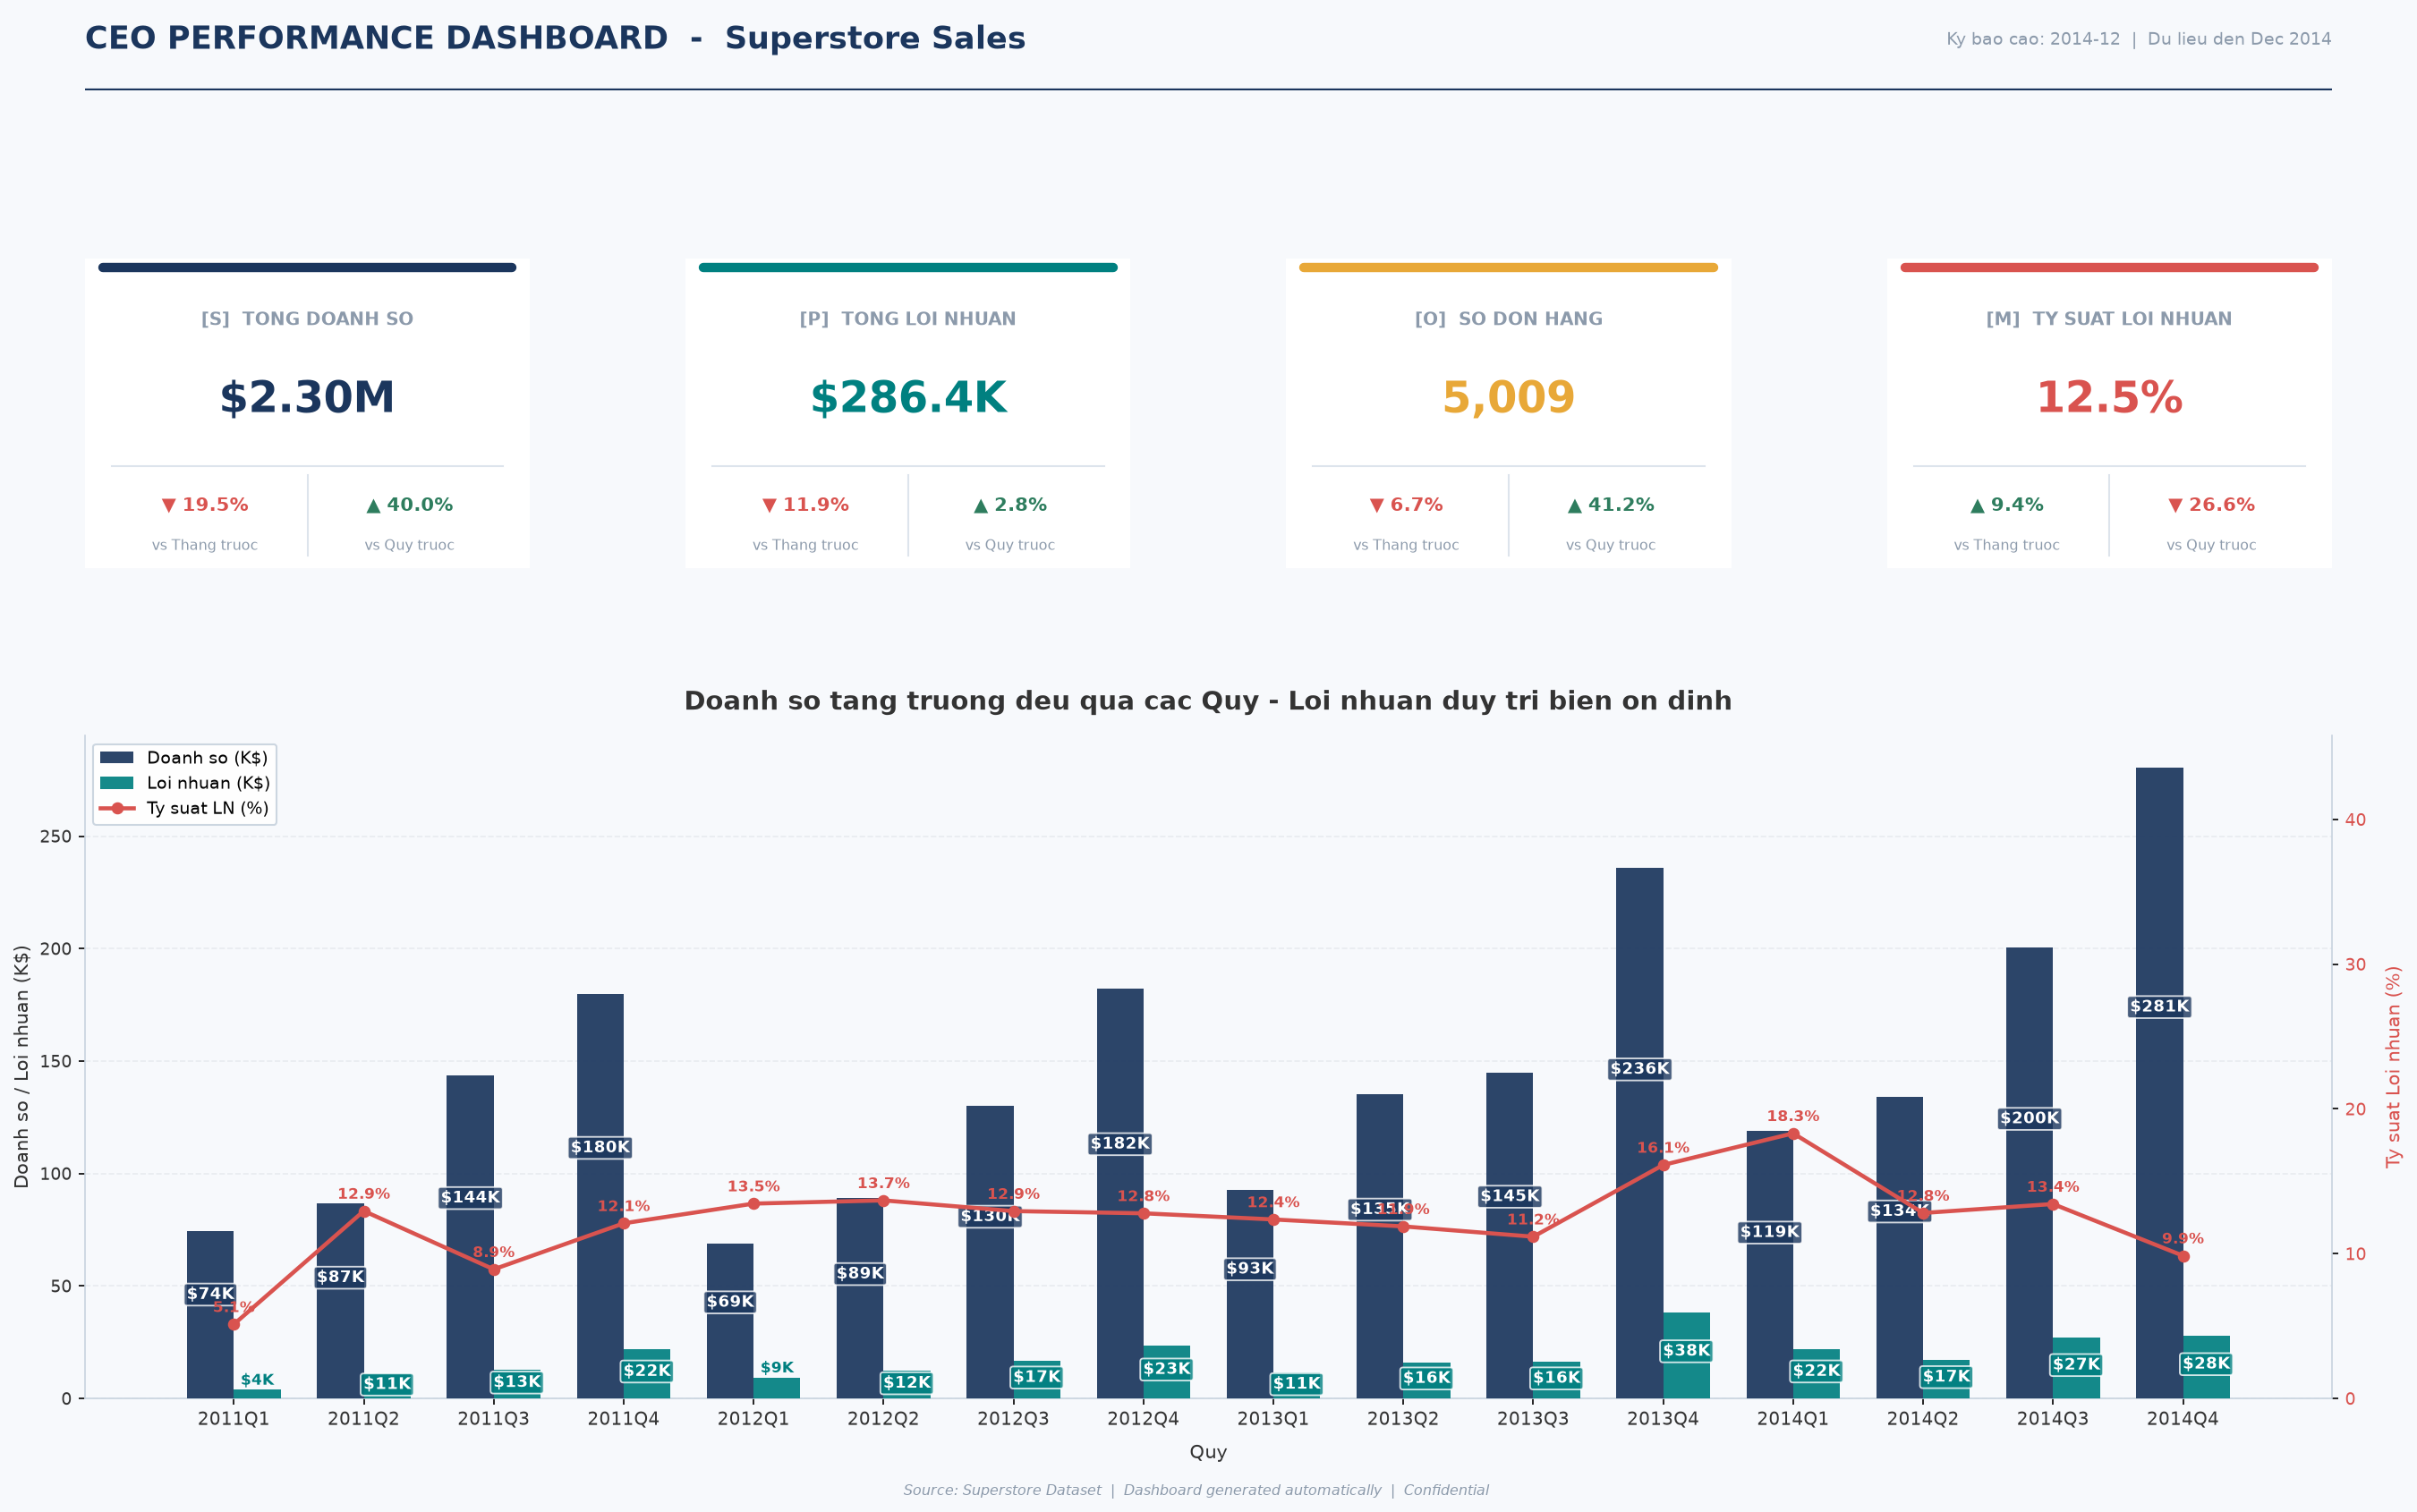

Dashboard saved: ceo_dashboard.png


In [4]:
# ── Palette ───────────────────────────────────────────────────────────────
C_NAVY  = '#1b365d'
C_TEAL  = '#008080'
C_RED   = '#d9534f'
C_AMBER = '#e8a838'
C_BG    = '#f7f9fc'
C_CARD  = '#ffffff'
C_GRAY  = '#333333'
C_LGRAY = '#8c9aab'
C_UP    = '#2e7d5e'
C_DOWN  = '#d9534f'

matplotlib.rcParams.update({'font.family': 'DejaVu Sans'})

# ── Layout ────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 12), dpi=150)
fig.patch.set_facecolor(C_BG)
gs = GridSpec(
    nrows=3, ncols=4, figure=fig,
    height_ratios=[0.07, 0.28, 0.60],
    hspace=0.48, wspace=0.35,
    left=0.04, right=0.97, top=0.93, bottom=0.07
)

# ── Dashboard title ───────────────────────────────────────────────────────
ax_title = fig.add_subplot(gs[0, :])
ax_title.axis('off')
ax_title.set_facecolor(C_BG)
ax_title.text(0.0, 0.65,
    'CEO PERFORMANCE DASHBOARD  -  Superstore Sales',
    fontsize=17, fontweight='bold', color=C_NAVY,
    va='center', ha='left', transform=ax_title.transAxes)
ax_title.text(1.0, 0.65,
    f'Ky bao cao: {latest_month}  |  Du lieu den {df["Order Date"].max().strftime("%b %Y")}',
    fontsize=9, color=C_LGRAY, va='center', ha='right',
    transform=ax_title.transAxes)
ax_title.axhline(y=0, color=C_NAVY, linewidth=2.5)

# ── KPI Card helper ───────────────────────────────────────────────────────
def draw_kpi_card(ax, title, value_str, mom_pct, qoq_pct,
                  accent=C_NAVY, icon=''):
    ax.set_facecolor(C_CARD)
    for sp in ax.spines.values(): sp.set_visible(False)
    ax.set_xticks([]); ax.set_yticks([])
    # Accent top bar
    ax.plot([0.04, 0.96], [0.97, 0.97], color=accent, linewidth=5,
            solid_capstyle='round', transform=ax.transAxes, clip_on=False)
    # Title
    ax.text(0.5, 0.80, f'{icon}  {title}',
            transform=ax.transAxes, fontsize=9.5, color=C_LGRAY,
            ha='center', va='center', fontweight='bold')
    # Big value
    ax.text(0.5, 0.54, value_str,
            transform=ax.transAxes, fontsize=23, fontweight='bold',
            color=accent, ha='center', va='center')
    # Divider
    ax.plot([0.06, 0.94], [0.33, 0.33], color='#dde4ec', linewidth=1,
            transform=ax.transAxes, clip_on=False)
    # MoM
    mc = C_UP if mom_pct >= 0 else C_DOWN
    ma = 'u25b2' if mom_pct >= 0 else 'u25bc'
    ax.text(0.27, 0.20,
            ('\u25b2' if mom_pct >= 0 else '\u25bc') + f' {abs(mom_pct):.1f}%',
            transform=ax.transAxes, fontsize=10, fontweight='bold',
            color=mc, ha='center', va='center')
    ax.text(0.27, 0.07, 'vs Thang truoc',
            transform=ax.transAxes, fontsize=7.5,
            color=C_LGRAY, ha='center', va='center')
    # Center divider
    ax.plot([0.5, 0.5], [0.04, 0.30], color='#dde4ec', linewidth=1,
            transform=ax.transAxes, clip_on=False)
    # QoQ
    qc = C_UP if qoq_pct >= 0 else C_DOWN
    ax.text(0.73, 0.20,
            ('\u25b2' if qoq_pct >= 0 else '\u25bc') + f' {abs(qoq_pct):.1f}%',
            transform=ax.transAxes, fontsize=10, fontweight='bold',
            color=qc, ha='center', va='center')
    ax.text(0.73, 0.07, 'vs Quy truoc',
            transform=ax.transAxes, fontsize=7.5,
            color=C_LGRAY, ha='center', va='center')

# ── Draw 4 KPI cards ──────────────────────────────────────────────────────
kpi_cfg = [
    (0, 'TONG DOANH SO',      f'${total_sales/1e6:.2f}M',
     pct_change(cur_m["sales"],   prev_m["sales"]),
     pct_change(cur_q["sales"],   prev_q["sales"]),  C_NAVY,  '[S]'),
    (1, 'TONG LOI NHUAN',     f'${total_profit/1e3:.1f}K',
     pct_change(cur_m["profit"],  prev_m["profit"]),
     pct_change(cur_q["profit"],  prev_q["profit"]), C_TEAL,  '[P]'),
    (2, 'SO DON HANG',        f'{total_orders:,}',
     pct_change(cur_m["orders"],  prev_m["orders"]),
     pct_change(cur_q["orders"],  prev_q["orders"]), C_AMBER, '[O]'),
    (3, 'TY SUAT LOI NHUAN',  f'{total_margin:.1f}%',
     pct_change(cur_m["margin"],  prev_m["margin"]),
     pct_change(cur_q["margin"],  prev_q["margin"]), C_RED,   '[M]'),
]
for col, title, val, mom, qoq, color, icon in kpi_cfg:
    ax = fig.add_subplot(gs[1, col])
    draw_kpi_card(ax, title, val, mom, qoq, accent=color, icon=icon)

# ═══════════════════════════════════════════════════════════════════════════
# Biểu đồ cột: Doanh số & Lợi nhuận theo Quý
# Labels: BÊN TRONG cột, màu trắng, bold – nổi bật
# ═══════════════════════════════════════════════════════════════════════════
ax_bar = fig.add_subplot(gs[2, :])
ax_bar.set_facecolor(C_BG)

x        = np.arange(len(quarterly))
bar_w    = 0.36
sales_k  = quarterly['Sales'].values   / 1e3
profit_k = quarterly['Profit'].values  / 1e3
labels   = quarterly['Quarter_str'].tolist()

bars1 = ax_bar.bar(x - bar_w/2, sales_k,  width=bar_w,
                   color=C_NAVY, alpha=0.92, label='Doanh so (K$)',  zorder=3)
bars2 = ax_bar.bar(x + bar_w/2, profit_k, width=bar_w,
                   color=C_TEAL, alpha=0.92, label='Loi nhuan (K$)', zorder=3)

# ── Labels cột Doanh số: bên TRONG nếu cột đủ cao, bên NGOÀI nếu thấp ─────
SALES_THRESH = sales_k.max() * 0.15  # ngưỡng tối thiểu để đặt label bên trong
for bar in bars1:
    h = bar.get_height()
    cx = bar.get_x() + bar.get_width() / 2
    if h >= SALES_THRESH:
        # Đủ cao: label BÊN TRONG cột (70% chiều cao), chữ trắng nổi bật
        ax_bar.text(
            cx, h * 0.62,
            f'${h:,.0f}K',
            ha='center', va='center',
            fontsize=8.5, fontweight='bold',
            color='white',
            zorder=5,
            bbox=dict(boxstyle='round,pad=0.18', facecolor=C_NAVY,
                      edgecolor='white', alpha=0.80, linewidth=0.9)
        )
    else:
        # Cột ngắn: label BÊN TRÊN ngoài cột, chữ Navy
        ax_bar.text(
            cx, h + sales_k.max() * 0.012,
            f'${h:,.0f}K',
            ha='center', va='bottom',
            fontsize=8, fontweight='bold', color=C_NAVY, zorder=5
        )

# ── Labels cột Lợi nhuận: bên TRONG nếu đủ cao, bên NGOÀI nếu thấp ─────────
PROFIT_THRESH = profit_k[profit_k > 0].max() * 0.25  # ngưỡng tối thiểu
for bar in bars2:
    h = bar.get_height()
    cx = bar.get_x() + bar.get_width() / 2
    if h >= PROFIT_THRESH:
        # Đủ cao: label BÊN TRONG cột, chữ trắng nổi bật
        ax_bar.text(
            cx, h * 0.55,
            f'${h:,.0f}K',
            ha='center', va='center',
            fontsize=8.5, fontweight='bold',
            color='white',
            zorder=5,
            bbox=dict(boxstyle='round,pad=0.18', facecolor=C_TEAL,
                      edgecolor='white', alpha=0.80, linewidth=0.9)
        )
    elif h > 0:
        # Cột thấp dương: label BÊN TRÊN ngoài, chữ Teal
        ax_bar.text(
            cx, h + profit_k[profit_k > 0].max() * 0.018,
            f'${h:,.0f}K',
            ha='center', va='bottom',
            fontsize=8, fontweight='bold', color=C_TEAL, zorder=5
        )
    else:
        # Cột âm: label phía dưới, màu đỏ
        ax_bar.text(
            cx, h - profit_k[profit_k > 0].max() * 0.02,
            f'${h:,.0f}K',
            ha='center', va='top',
            fontsize=8, fontweight='bold', color=C_RED, zorder=5
        )

# ── Profit Margin line (trục phụ) ─────────────────────────────────────────
ax2 = ax_bar.twinx()
ax2.plot(x, quarterly['Margin'].values,
         color=C_RED, marker='o', linewidth=2.2,
         markersize=5.5, label='Ty suat LN (%)', zorder=4)
ax2.set_ylabel('Ty suat Loi nhuan (%)', fontsize=10, color=C_RED, labelpad=10)
ax2.tick_params(axis='y', labelcolor=C_RED, labelsize=9)
ax2.set_ylim(0, quarterly['Margin'].max() * 2.5)
ax2.spines['top'].set_visible(False)
ax2.spines['left'].set_visible(False)
ax2.spines['bottom'].set_visible(False)
ax2.spines['right'].set_color('#c8d3de')
# Labels Margin
for i, v in enumerate(quarterly['Margin'].values):
    ax2.text(i, v + 0.6, f'{v:.1f}%',
             ha='center', va='bottom', fontsize=8,
             color=C_RED, fontweight='bold')

# ── Axes styling ──────────────────────────────────────────────────────────
ax_bar.set_xticks(x)
ax_bar.set_xticklabels(labels, fontsize=9.5, color=C_GRAY)
ax_bar.set_ylabel('Doanh so / Loi nhuan (K$)', fontsize=10, color=C_GRAY)
ax_bar.set_xlabel('Quy', fontsize=10, color=C_GRAY, labelpad=8)
ax_bar.spines['top'].set_visible(False)
ax_bar.spines['right'].set_visible(False)
ax_bar.spines['left'].set_color('#c8d3de')
ax_bar.spines['bottom'].set_color('#c8d3de')
ax_bar.yaxis.grid(True, alpha=0.2, color='#aab5c0', linestyle='--')
ax_bar.set_axisbelow(True)
ax_bar.tick_params(axis='y', labelsize=9, labelcolor=C_GRAY)
ax_bar.set_title(
    'Doanh so tang truong deu qua cac Quy - Loi nhuan duy tri bien on dinh',
    fontsize=14, fontweight='bold', color=C_GRAY, pad=14
)

# ── Legend ────────────────────────────────────────────────────────────────
h1, l1 = ax_bar.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax_bar.legend(h1 + h2, l1 + l2,
              loc='upper left', fontsize=9,
              frameon=True, framealpha=0.92,
              edgecolor='#c8d3de', facecolor='white')

# ── Footer ────────────────────────────────────────────────────────────────
fig.text(0.5, 0.01,
    'Source: Superstore Dataset  |  Dashboard generated automatically  |  Confidential',
    ha='center', fontsize=7.5, color=C_LGRAY, style='italic')

plt.savefig('ceo_dashboard.png', dpi=300, bbox_inches='tight', facecolor=C_BG)
plt.show()
print('Dashboard saved: ceo_dashboard.png')


---
## KPI Reference

| KPI | Y nghia | Benchmark |
|-----|---------|----------|
| **Tong Doanh so** | Tong doanh thu tat ca don hang | MoM >= 5% |
| **Tong Loi nhuan** | Doanh so - chi phi hang ban | MoM >= 8% |
| **So Don hang** | So Order ID duy nhat | Volume khach hang |
| **Ty suat LN (%)** | Profit / Sales x 100 | Muc tieu >= 12% |

> **MoM / QoQ** tinh theo ky gan nhat trong dataset so voi ky lien truoc.

---
## 🗺️ Section 2 – Geo Market Intelligence
> Bản đồ Hoa Kỳ tô màu theo Doanh số, bong bóng Lợi nhuận, Pie chart theo Vùng, bảng Top/Bottom states và **Region Slicer** tương tác.

In [5]:

import plotly.graph_objects as go
import plotly.io as pio
import matplotlib.patches as mpatches
from matplotlib.lines import Line2D
import os

# State name → 2-letter abbreviation
STATE_ABBR = {
    'Alabama':'AL','Alaska':'AK','Arizona':'AZ','Arkansas':'AR',
    'California':'CA','Colorado':'CO','Connecticut':'CT','Delaware':'DE',
    'Florida':'FL','Georgia':'GA','Hawaii':'HI','Idaho':'ID',
    'Illinois':'IL','Indiana':'IN','Iowa':'IA','Kansas':'KS',
    'Kentucky':'KY','Louisiana':'LA','Maine':'ME','Maryland':'MD',
    'Massachusetts':'MA','Michigan':'MI','Minnesota':'MN','Mississippi':'MS',
    'Missouri':'MO','Montana':'MT','Nebraska':'NE','Nevada':'NV',
    'New Hampshire':'NH','New Jersey':'NJ','New Mexico':'NM','New York':'NY',
    'North Carolina':'NC','North Dakota':'ND','Ohio':'OH','Oklahoma':'OK',
    'Oregon':'OR','Pennsylvania':'PA','Rhode Island':'RI','South Carolina':'SC',
    'South Dakota':'SD','Tennessee':'TN','Texas':'TX','Utah':'UT',
    'Vermont':'VT','Virginia':'VA','Washington':'WA','West Virginia':'WV',
    'Wisconsin':'WI','Wyoming':'WY','District of Columbia':'DC'
}

STATE_CENTERS = {
    'AL':(32.8,-86.8),'AK':(64.2,-153.4),'AZ':(34.3,-111.1),'AR':(34.9,-92.4),
    'CA':(36.8,-119.4),'CO':(39.1,-105.4),'CT':(41.6,-72.7),'DE':(39.0,-75.5),
    'FL':(27.7,-81.7),'GA':(32.7,-83.4),'HI':(20.8,-156.3),'ID':(44.4,-114.5),
    'IL':(40.0,-89.2),'IN':(39.9,-86.3),'IA':(42.1,-93.5),'KS':(38.5,-98.4),
    'KY':(37.7,-84.7),'LA':(30.9,-91.8),'ME':(44.7,-69.4),'MD':(39.1,-76.8),
    'MA':(42.2,-71.5),'MI':(44.3,-85.4),'MN':(46.4,-93.1),'MS':(32.7,-89.7),
    'MO':(38.5,-92.5),'MT':(47.0,-110.5),'NE':(41.5,-99.9),'NV':(38.5,-117.1),
    'NH':(43.9,-71.6),'NJ':(40.1,-74.5),'NM':(34.4,-106.1),'NY':(42.9,-75.5),
    'NC':(35.5,-79.4),'ND':(47.5,-100.5),'OH':(40.4,-82.7),'OK':(35.6,-96.9),
    'OR':(44.1,-120.5),'PA':(40.9,-77.8),'RI':(41.7,-71.5),'SC':(33.9,-80.9),
    'SD':(44.4,-100.2),'TN':(35.9,-86.7),'TX':(31.5,-99.3),'UT':(39.4,-111.1),
    'VT':(44.0,-72.7),'VA':(37.8,-78.2),'WA':(47.4,-120.5),'WV':(38.6,-80.5),
    'WI':(44.3,-89.8),'WY':(43.0,-107.6),'DC':(38.9,-77.0)
}

REGION_COLORS = {'East': C_NAVY, 'West': C_TEAL, 'Central': C_AMBER, 'South': C_RED}
REGIONS_ALL   = ['All'] + sorted(df['Region'].dropna().unique().tolist())
STATE_REGION  = df.groupby('State')['Region'].first().to_dict()

def geo_aggregate(region_filter='All'):
    sub = df if region_filter == 'All' else df[df['Region'] == region_filter]
    by_state = (
        sub.groupby('State')
           .agg(Sales=('Sales','sum'), Profit=('Profit','sum'),
                Orders=('Order ID','nunique'))
           .reset_index()
    )
    by_state['Abbr']   = by_state['State'].map(STATE_ABBR)
    by_state['Margin'] = by_state['Profit'] / by_state['Sales'] * 100
    by_state['Region'] = by_state['State'].map(STATE_REGION)
    by_state = by_state.dropna(subset=['Abbr'])
    by_region = (
        sub.groupby('Region')
           .agg(Sales=('Sales','sum'), Profit=('Profit','sum'))
           .reset_index().sort_values('Sales', ascending=False)
    )
    return by_state, by_region

print(f'Geo helpers ready | {df["State"].nunique()} states | {df["Region"].nunique()} regions')

Geo helpers ready | 49 states | 4 regions


In [6]:

def build_geo_section(region_filter='All', save_png=True):
    by_state, by_region = geo_aggregate(region_filter)
    title_sfx = f' – {region_filter}' if region_filter != 'All' else ' – All Regions'

    # ── PLOTLY choropleth ─────────────────────────────────────────────────
    max_p = by_state['Profit'].abs().max()
    bsize = (by_state['Profit'].abs() / max_p * 42 + 4).clip(lower=4)
    bcolor= [C_UP if p >= 0 else C_DOWN for p in by_state['Profit']]
    lats  = by_state['Abbr'].map(lambda a: STATE_CENTERS.get(a,(None,None))[0])
    lons  = by_state['Abbr'].map(lambda a: STATE_CENTERS.get(a,(None,None))[1])
    hover = [
        f"<b>{r['State']}</b><br>Sales: ${r['Sales']:,.0f}<br>"
        f"Profit: ${r['Profit']:,.0f}<br>Margin: {r['Margin']:.1f}%<br>Orders: {r['Orders']:,}"
        for _, r in by_state.iterrows()
    ]
    colorscale = [[0.0,'#dce8f5'],[0.3,'#4e8ab5'],[0.6,C_NAVY],[1.0,'#0a1e38']]

    fig_map = go.Figure()
    fig_map.add_trace(go.Choropleth(
        locations=by_state['Abbr'], z=by_state['Sales'],
        locationmode='USA-states', colorscale=colorscale,
        colorbar=dict(title=dict(text='Sales ($)',font=dict(size=11,color=C_GRAY)),
                      thickness=14, len=0.6, x=1.01,
                      tickprefix='$', tickfont=dict(size=10)),
        hoverinfo='skip',
        marker_line_color='white', marker_line_width=1.2,
    ))
    fig_map.add_trace(go.Scattergeo(
        lon=lons, lat=lats, mode='markers',
        marker=dict(size=bsize, color=bcolor, opacity=0.82,
                    line=dict(color='white', width=1.2)),
        text=hover, hovertemplate='%{text}<extra></extra>',
        name='Loi nhuan',
    ))
    fig_map.update_layout(
        title=dict(
            text=f'<b>Doanh so & Loi nhuan theo Tieu bang{title_sfx}</b>',
            font=dict(size=15, color=C_NAVY, family='Arial'),
            x=0.5, xanchor='center', y=0.97
        ),
        geo=dict(scope='usa', showlakes=True, lakecolor='#d0e8f7',
                 bgcolor=C_BG, landcolor='#e8eff7', showland=True),
        paper_bgcolor=C_BG, plot_bgcolor=C_BG,
        margin=dict(l=0, r=0, t=48, b=8),
        height=420,
        legend=dict(x=0.01, y=0.05, bgcolor='rgba(255,255,255,0.85)',
                    bordercolor='#c8d3de', borderwidth=1, font=dict(size=10))
    )

    map_path = f'geo_map_{region_filter.lower().replace(" ","_")}.png'
    try:
        fig_map.write_image(map_path, width=1100, height=420, scale=2)
    except Exception as e:
        print(f'[kaleido] {e}'); map_path = None

    # ── MATPLOTLIB: Pie + Ranking ─────────────────────────────────────────
    fig2, axes = plt.subplots(1, 2, figsize=(15, 6.5), dpi=150,
                              facecolor=C_BG,
                              gridspec_kw={'width_ratios':[1, 1.6]})
    fig2.patch.set_facecolor(C_BG)

    # PIE
    ax_pie = axes[0]; ax_pie.set_facecolor(C_BG)
    pie_labels = by_region['Region'].tolist()
    pie_sizes  = by_region['Sales'].tolist()
    pie_colors = [REGION_COLORS.get(r, C_LGRAY) for r in pie_labels]
    total_s    = sum(pie_sizes)

    wedges, _, autotexts = ax_pie.pie(
        pie_sizes, labels=None, colors=pie_colors,
        autopct='%1.1f%%', pctdistance=0.72, startangle=90,
        wedgeprops=dict(width=0.52, edgecolor='white', linewidth=2.5),
        textprops=dict(fontsize=10)
    )
    for at in autotexts:
        at.set_fontweight('bold'); at.set_fontsize(10); at.set_color('white')
    ax_pie.text(0,  0.10, 'DOANH SO', ha='center', va='center',
               fontsize=8, color=C_LGRAY, fontweight='bold')
    ax_pie.text(0, -0.18, f'${total_s/1e6:.2f}M', ha='center', va='center',
               fontsize=14, color=C_NAVY, fontweight='bold')
    legend_items = [
        mpatches.Patch(color=c, label=f'{r}: ${s/1e3:.0f}K ({s/total_s*100:.1f}%)')
        for r, s, c in zip(pie_labels, pie_sizes, pie_colors)
    ]
    ax_pie.legend(handles=legend_items, loc='lower center',
                  bbox_to_anchor=(0.5, -0.22), fontsize=9,
                  frameon=True, framealpha=0.9, edgecolor='#c8d3de', ncol=2)
    ax_pie.set_title('Phan bo Doanh so theo Vung (Region)',
                     fontsize=12, fontweight='bold', color=C_GRAY, pad=12)
    ax_pie.spines['top'].set_visible(False)
    ax_pie.spines['right'].set_visible(False)

    # RANKING TABLE
    ax_tbl = axes[1]; ax_tbl.set_facecolor(C_BG); ax_tbl.axis('off')
    TOP_N  = 5
    top5    = by_state.nlargest(TOP_N, 'Profit').reset_index(drop=True)
    bottom5 = by_state.nsmallest(TOP_N, 'Profit').reset_index(drop=True)

    def table_block(ax, data, title, ystart, accent):
        ax.text(0.02, ystart + 0.065, title, transform=ax.transAxes,
               fontsize=11, fontweight='bold', color=accent, va='bottom')
        ax.plot([0.02, 0.98], [ystart - 0.008, ystart - 0.008],
                color=accent, linewidth=1.5, alpha=0.6,
                transform=ax.transAxes, clip_on=False)
        headers = ['Rank', 'State', 'Sales', 'Profit', 'Margin']
        col_x   = [0.03, 0.13, 0.44, 0.63, 0.83]
        yh = ystart - 0.065
        for h, cx in zip(headers, col_x):
            ax.text(cx, yh, h, transform=ax.transAxes, fontsize=8.5,
                   fontweight='bold', color=C_LGRAY, va='center')
        row_h = 0.083
        for i, (_, row) in enumerate(data.iterrows()):
            y = yh - (i + 1) * row_h
            if i % 2 == 0:
                ax.add_patch(mpatches.FancyBboxPatch(
                    (0.01, y - 0.026), 0.97, row_h * 0.94,
                    boxstyle='round,pad=0.005', transform=ax.transAxes,
                    clip_on=False, facecolor='#edf2f8', edgecolor='none', zorder=0))
            pc = C_UP if row['Profit'] >= 0 else C_DOWN
            vals = [f'#{i+1}', row['State'][:18],
                    f"${row['Sales']/1e3:.1f}K",
                    f"${row['Profit']/1e3:.1f}K",
                    f"{row['Margin']:.1f}%"]
            clrs = [C_GRAY, C_NAVY, C_GRAY, pc, C_GRAY]
            wts  = ['bold','bold','normal','bold','normal']
            for v, cx, vc, wt in zip(vals, col_x, clrs, wts):
                ax.text(cx, y + 0.01, v, transform=ax.transAxes,
                       fontsize=8.5, color=vc, fontweight=wt, va='center')

    table_block(ax_tbl, top5,    'TOP 5 – Loi nhuan cao nhat',    0.95, C_UP)
    table_block(ax_tbl, bottom5, 'BOTTOM 5 – Loi nhuan thap nhat', 0.46, C_DOWN)

    fig2.suptitle(f'Phan tich thi truong theo Vung{title_sfx}',
                  fontsize=14, fontweight='bold', color=C_NAVY, y=1.01)
    plt.tight_layout(pad=1.5)
    out2 = f'geo_charts_{region_filter.lower().replace(" ","_")}.png'
    fig2.savefig(out2, dpi=300, bbox_inches='tight', facecolor=C_BG)
    plt.show()

    # Show map
    if map_path and os.path.exists(map_path):
        fig_m, ax_m = plt.subplots(figsize=(15, 5.5), dpi=120, facecolor=C_BG)
        ax_m.imshow(plt.imread(map_path)); ax_m.axis('off')
        ax_m.legend(handles=[
            Line2D([0],[0], marker='o', color='w', markerfacecolor=C_UP,
                   markersize=10, label='Loi nhuan duong (+)'),
            Line2D([0],[0], marker='o', color='w', markerfacecolor=C_DOWN,
                   markersize=10, label='Loi nhuan am (-)'),
        ], loc='lower left', fontsize=9, frameon=True, framealpha=0.9,
           edgecolor='#c8d3de', facecolor='white')
        plt.tight_layout(pad=0); plt.show()
    else:
        pio.renderers.default = 'notebook'
        fig_map.show()

    print(f'[{region_filter}] States={len(by_state)} | '
          f'Sales=${by_state["Sales"].sum()/1e6:.2f}M | '
          f'Profit=${by_state["Profit"].sum()/1e3:.1f}K')

print('build_geo_section() ready.')

build_geo_section() ready.


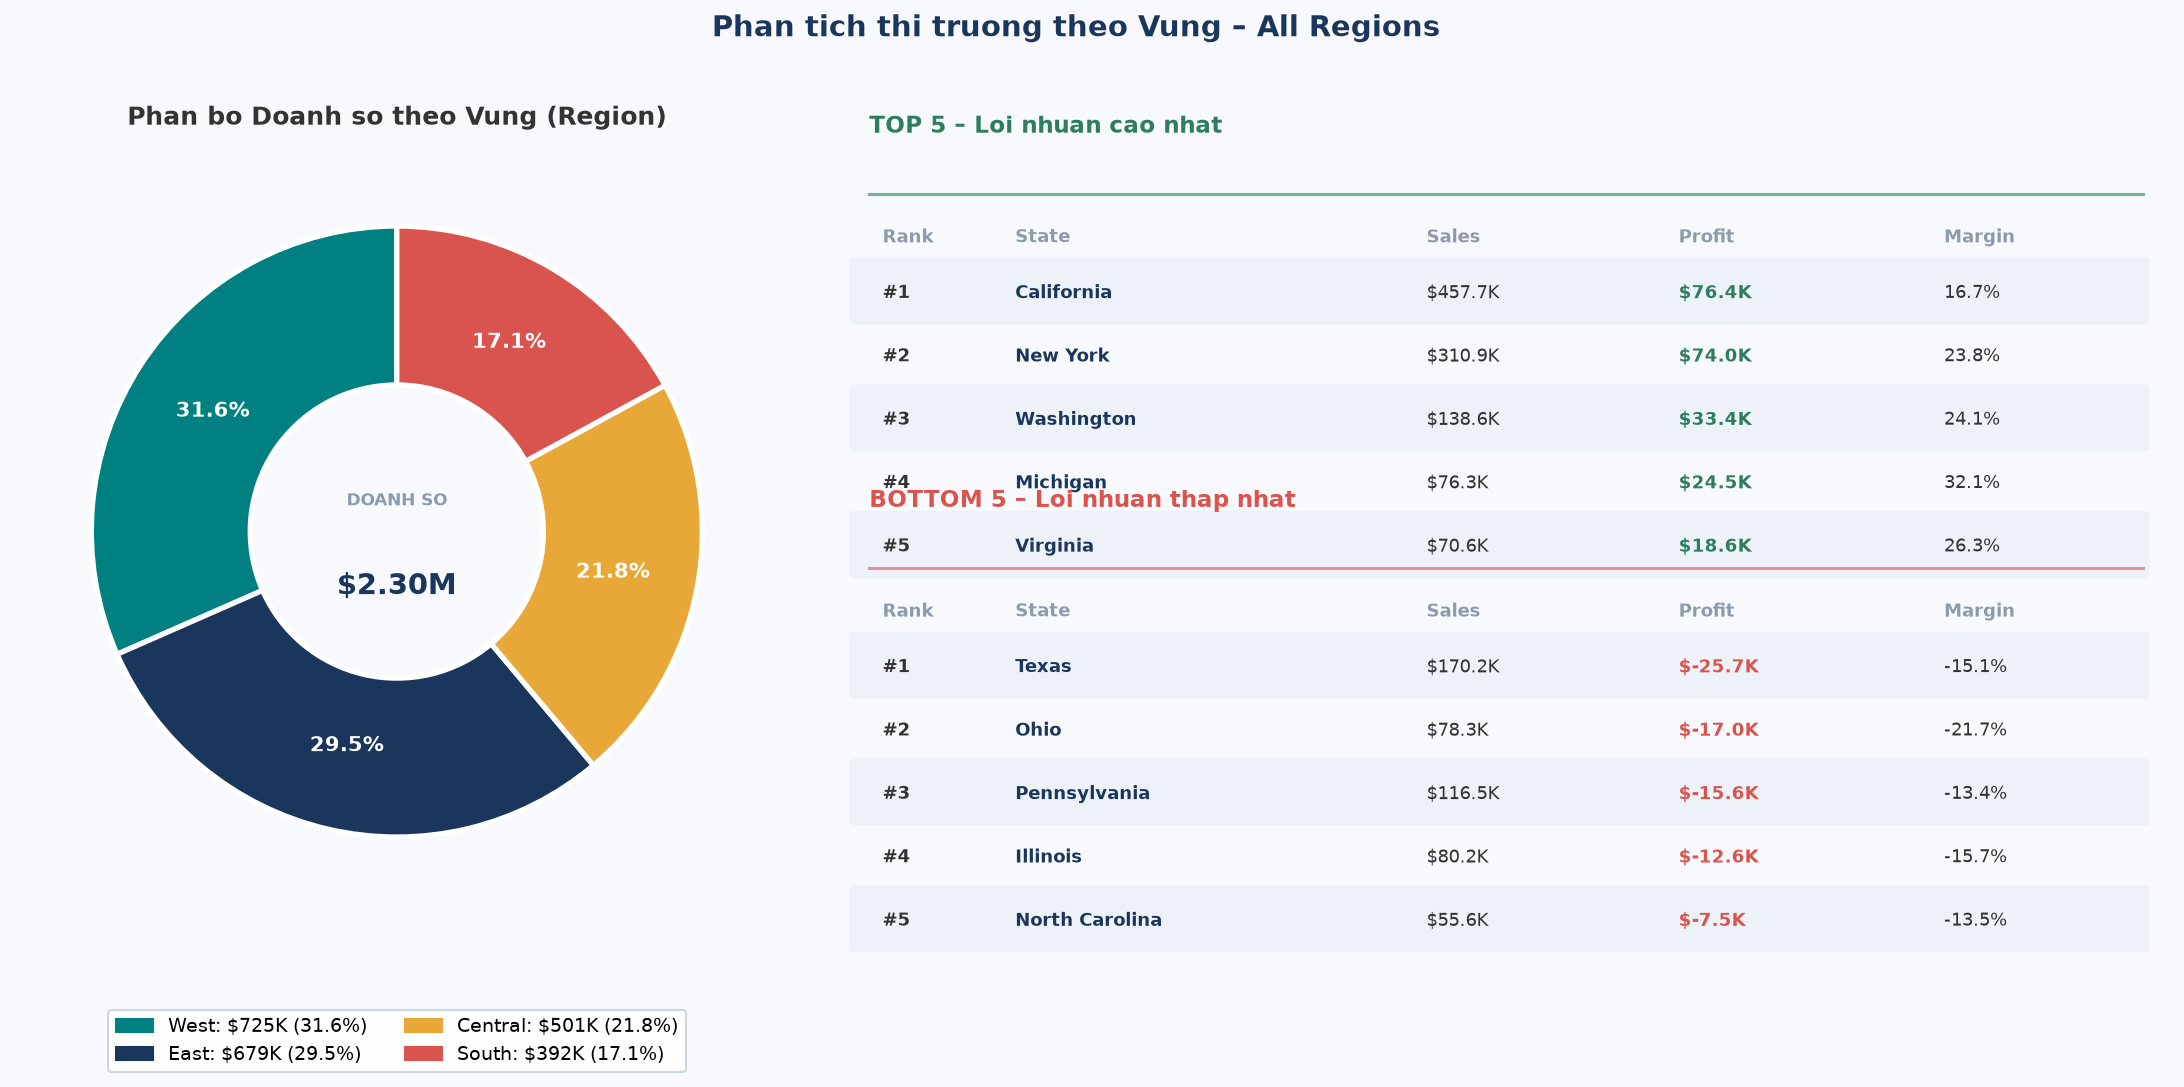

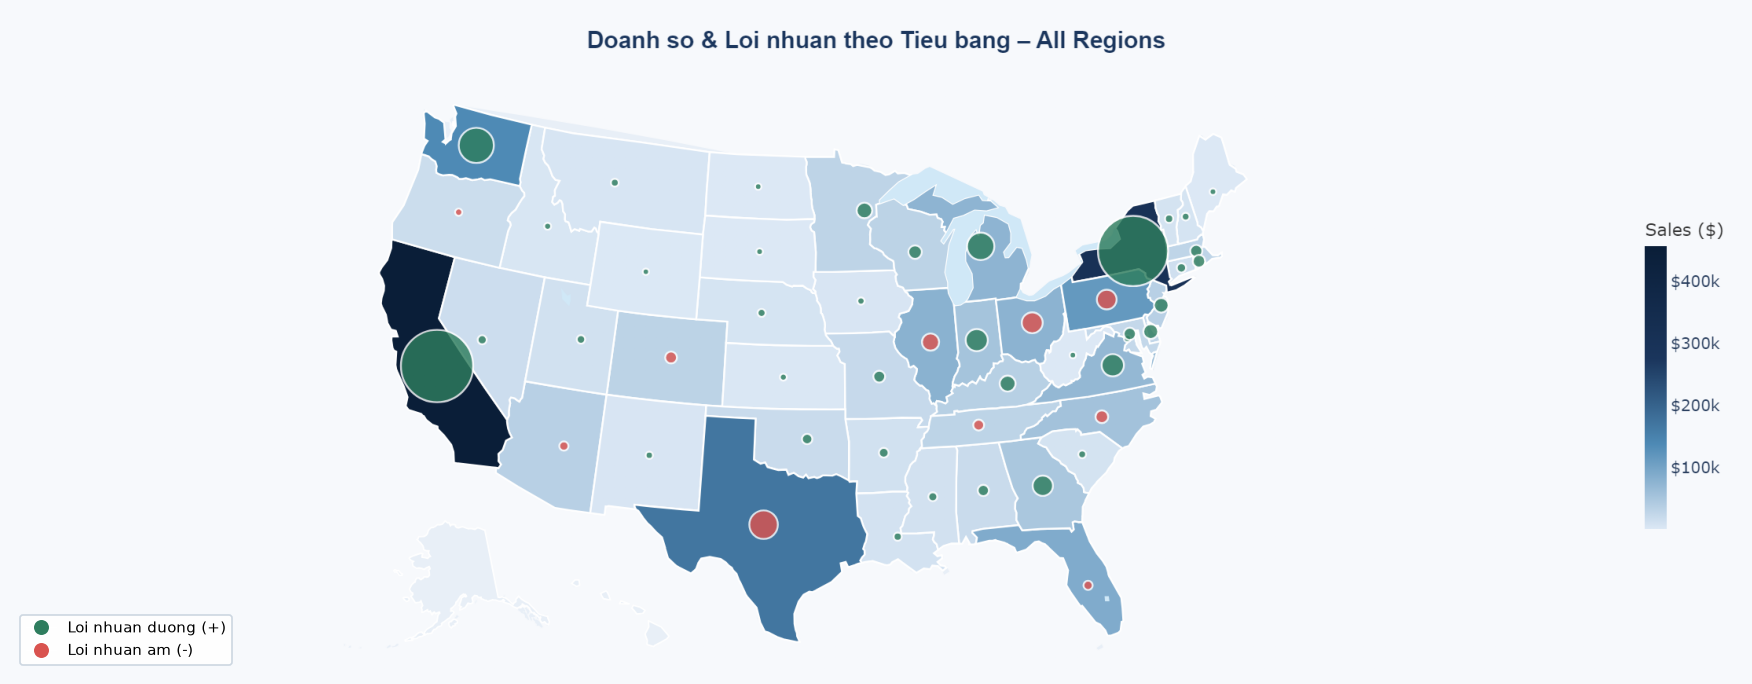

[All] States=49 | Sales=$2.30M | Profit=$286.4K


In [7]:

# Static render – All Regions (luon hien thi khi chay notebook)
build_geo_section('All', save_png=True)

In [8]:
# ── Interactive Region Slicer ──────────────────────────────────────────────
try:
    import ipywidgets as widgets
    from IPython.display import display, clear_output

    if 'REGIONS_ALL' not in globals():
        REGIONS_ALL = ['All'] + sorted(df['Region'].dropna().unique().tolist())

    out_geo = widgets.Output()

    region_dd = widgets.Dropdown(
        options=REGIONS_ALL, value='All',
        description='Region:',
        style={'description_width': '60px'},
        layout=widgets.Layout(width='230px')
    )
    hdr = widgets.HTML(
        '<b style="font-size:14px;color:#1b365d;">Region Slicer – '
        'Khoanh vung thi truong tiem nang</b>'
    )

    def on_region_change(change):
        if change['name'] == 'value':
            with out_geo:
                clear_output(wait=True)
                build_geo_section(change['new'], save_png=False)

    region_dd.observe(on_region_change, names='value')

    ui_geo = widgets.VBox([
        hdr,
        widgets.HBox([
            widgets.Label('Chon vung de xem ban do va bang xep hang:'),
            region_dd
        ]),
        out_geo
    ], layout=widgets.Layout(padding='10px'))

    display(ui_geo)
    with out_geo:
        build_geo_section('All', save_png=False)

except ImportError:
    print('ipywidgets not available – showing static view.')
    build_geo_section('All', save_png=False)

In [9]:

# Regional KPI Summary Table
summary = (
    df.groupby('Region')
      .agg(Sales=('Sales','sum'), Profit=('Profit','sum'),
           Orders=('Order ID','nunique'), States=('State','nunique'))
      .reset_index().sort_values('Sales', ascending=False)
)
summary['Margin_%']  = (summary['Profit'] / summary['Sales'] * 100).round(1)
summary['Sales_$K']  = summary['Sales'].apply(lambda x: f'${x/1e3:,.1f}K')
summary['Profit_$K'] = summary['Profit'].apply(lambda x: f'${x/1e3:,.1f}K')
print('\n' + '='*65)
print('  REGIONAL KPI SUMMARY')
print('='*65)
print(summary[['Region','Sales_$K','Profit_$K','Margin_%','Orders','States']].to_string(index=False))
print('='*65)


  REGIONAL KPI SUMMARY
 Region Sales_$K Profit_$K  Margin_%  Orders  States
   West  $725.5K   $108.4K      14.9    1611      11
   East  $678.8K    $91.5K      13.5    1401      14
Central  $501.2K    $39.7K       7.9    1175      13
  South  $391.7K    $46.7K      11.9     822      11
